# Determination of Wind Speeds in Hamburg on February 18, 2022

In [1]:
import cdsapi
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import geopandas as gpd

## Download + visualization of the hourly data from ERA5

In [1]:
c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': [
            '10m_u_component_of_wind',
            '10m_v_component_of_wind',
        ],
        'year': '2022',
        'month': '02',
        'day': '18',
        'time': [f"{h:02d}:00" for h in range(24)],  # hourly
        'format': 'netcdf',
        'area': [54, 9.5, 53, 10.5],  # N, W, S, E (tight bounding box around Hamburg)
        'grid': [0.25, 0.25],  # ERA5 native resolution
    },
    'data/hamburg_wind_20220218.nc'
)


2025-05-07 09:14:30,560 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-05-07 09:14:30,560 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-05-07 09:14:30,996 INFO Request ID is 27bdc3ff-83dc-4131-9442-98972cefe300
2025-05-07 09:14:31,353 INFO status has been updated to accepted
2025-05-07 09:17:24,677 INFO status has been updated to successful


da263ed37dc9ad5112e63f59ba07c09e.nc:   0%|          | 0.00/36.2k [00:00<?, ?B/s]

'hamburg_wind_20220218.nc'

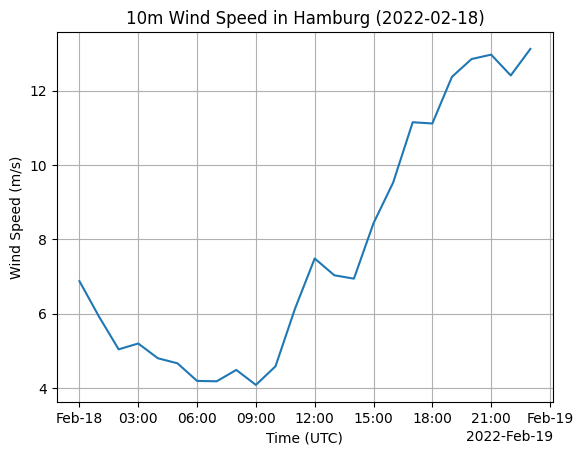

In [3]:
ds = xr.open_dataset("data/hamburg_wind_20220218.nc")

# Compute wind speed
u = ds['u10']
v = ds['v10']
wind_speed = np.sqrt(u**2 + v**2)

# Select the grid point closest to Hamburg (lat, lon)
hamburg_point = wind_speed.sel(latitude=53.55, longitude=10.00, method='nearest')

# Plot wind speed over time
hamburg_point.plot()
plt.title("10m Wind Speed in Hamburg (2022-02-18)")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.show()

## Show selected region

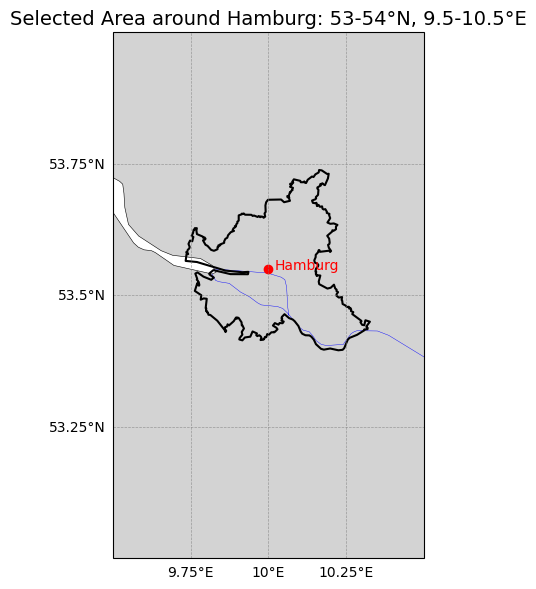

In [3]:
# Load Hamburg boundary from GADM Level 2 shapefile
gdf = gpd.read_file("data/gadm41_DEU_2.json")
hamburg_shape = gdf[gdf["NAME_1"] == "Hamburg"]

# Plot setup
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to match desired view
ax.set_extent([9.5, 10.5, 53.0, 54.0], crs=ccrs.PlateCarree())

# Add base map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.3)

# Plot Hamburg boundary
hamburg_shape.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, transform=ccrs.PlateCarree())

# Mark Hamburg city center
ax.plot(10.0, 53.55, 'ro', markersize=6, transform=ccrs.PlateCarree())
ax.text(10.02, 53.55, "Hamburg", color='red', transform=ccrs.PlateCarree())

# Gridlines with lat/lon ticks
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}
gl.xlocator = mticker.MultipleLocator(0.25)
gl.ylocator = mticker.MultipleLocator(0.25)

# Title
plt.title("Selected Area around Hamburg: 53-54°N, 9.5-10.5°E", fontsize=14)
plt.tight_layout()
plt.show()

## Determination of exact wind speeds for selected time points

The peak can be observed at 21:00 UTC, therefore it be chosen as the target. According to GraphCasts autoregressive structure, the model performs a one-step forecast using meteorological inputs from 6 and 12 hours prior, corresponding to 15:00 UTC and 09:00 UTC.

Determination of the exact wind speeds at 9:00, 15:00 and 21:00 UTC.

In [5]:
# Average spatially over the grid (lat, lon) to get one value per time
wind_speed_mean = wind_speed.mean(dim=["latitude", "longitude"])

wind_speed_mean = wind_speed_mean.rename({'valid_time': 'time'})


# Extract specific times
for target_time in ["2022-02-18T09:00", "2022-02-18T15:00", "2022-02-18T21:00"]:
    value = wind_speed_mean.sel(time=target_time).item()
    print(f"Wind speed at {target_time} UTC: {value:.2f} m/s")


Wind speed at 2022-02-18T09:00 UTC: 4.41 m/s
Wind speed at 2022-02-18T15:00 UTC: 8.27 m/s
Wind speed at 2022-02-18T21:00 UTC: 12.91 m/s


## Visualisation of the selected geospatial area with its according wind speeds

The wind speeds were averaged over the area of 53°N-54°N and 9.5°E-10.5°E in 0.25° steps. Here, the values and areas of the rectangles are shown for the peak time 21:00 UTC.

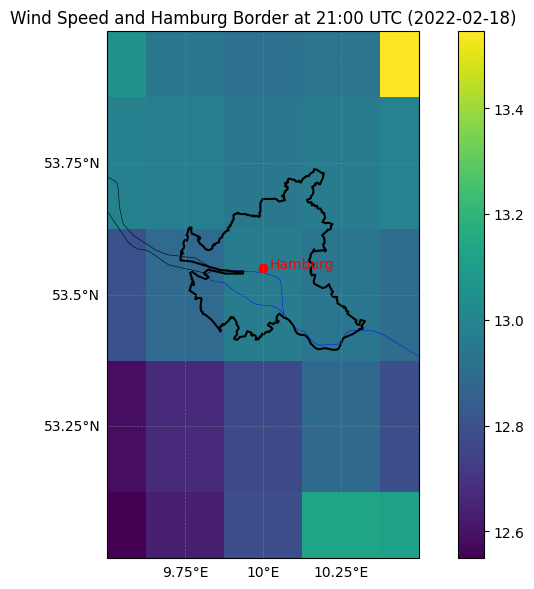

In [ ]:
# Load wind data
ds = xr.open_dataset("hamburg_wind_20220218.nc")
u = ds['u10']
v = ds['v10']
wind_speed = (u**2 + v**2) ** 0.5
wind_slice = wind_speed.sel(valid_time="2022-02-18T21:00")

# Load Hamburg boundary from GADM
gdf = gpd.read_file("data/gadm41_DEU_2.json") # Adjust path as necessary (download from GADM (Germany Level 2))
hamburg_shape = gdf[gdf["NAME_1"] == "Hamburg"]

# Plot setup
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to match your data grid
ax.set_extent([9.5, 10.5, 53.0, 54.0], crs=ccrs.PlateCarree())

# Wind speed plot
mesh = wind_slice.plot.pcolormesh(
    ax=ax, cmap="viridis", add_colorbar=True, transform=ccrs.PlateCarree()
)

# Add map context
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.3)

# Plot Hamburg boundary
hamburg_shape.boundary.plot(ax=ax, edgecolor="black", linewidth=1.5, transform=ccrs.PlateCarree())

# Mark Hamburg center
ax.plot(10.0, 53.55, 'ro', markersize=6, transform=ccrs.PlateCarree())
ax.text(10.02, 53.55, "Hamburg", color='red', transform=ccrs.PlateCarree())

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}
gl.xlocator = mticker.MultipleLocator(0.25)
gl.ylocator = mticker.MultipleLocator(0.25)

# Title
plt.title("Wind Speed and Hamburg Border at 21:00 UTC (2022-02-18)")
plt.tight_layout()
plt.show()

